In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
batch_size = 128
lr = 0.0002
latent_dim = 100
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:11<00:00, 895kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 97.8kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 288kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.82MB/s]


In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        return self.model(img_flat)

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=lr)
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr)

In [7]:
g_losses = []
d_losses = []

for epoch in range(epochs):
    for imgs, _ in dataloader:

        batch_size_curr = imgs.size(0)
        imgs = imgs.to(device)

        real_labels = torch.ones(batch_size_curr, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size_curr, 1).to(device)

        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = G(z)

        g_loss = criterion(D(fake_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

Epoch [1/50]  D Loss: 0.3437  G Loss: 6.9612
Epoch [2/50]  D Loss: 0.3469  G Loss: 5.7295
Epoch [3/50]  D Loss: 0.3525  G Loss: 5.9590
Epoch [4/50]  D Loss: 0.3958  G Loss: 5.6800
Epoch [5/50]  D Loss: 0.4643  G Loss: 5.1885
Epoch [6/50]  D Loss: 0.6258  G Loss: 4.4744
Epoch [7/50]  D Loss: 0.6531  G Loss: 2.5740
Epoch [8/50]  D Loss: 0.7146  G Loss: 1.5391
Epoch [9/50]  D Loss: 1.1829  G Loss: 1.3586
Epoch [10/50]  D Loss: 1.0138  G Loss: 1.0625
Epoch [11/50]  D Loss: 0.8137  G Loss: 1.5529
Epoch [12/50]  D Loss: 0.9693  G Loss: 2.8163
Epoch [13/50]  D Loss: 0.8277  G Loss: 1.6761
Epoch [14/50]  D Loss: 0.9217  G Loss: 2.9099
Epoch [15/50]  D Loss: 0.5720  G Loss: 1.8795
Epoch [16/50]  D Loss: 0.6309  G Loss: 2.1825
Epoch [17/50]  D Loss: 0.8393  G Loss: 3.0028
Epoch [18/50]  D Loss: 0.8299  G Loss: 1.8238
Epoch [19/50]  D Loss: 0.8007  G Loss: 1.8384
Epoch [20/50]  D Loss: 1.0091  G Loss: 1.5921
Epoch [21/50]  D Loss: 0.7355  G Loss: 1.8880
Epoch [22/50]  D Loss: 0.6869  G Loss: 1.44

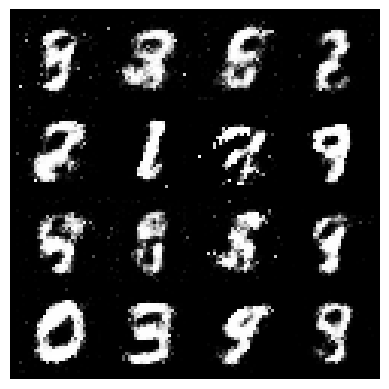

In [8]:
z = torch.randn(16, latent_dim).to(device)
generated_imgs = G(z).detach().cpu()

grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()

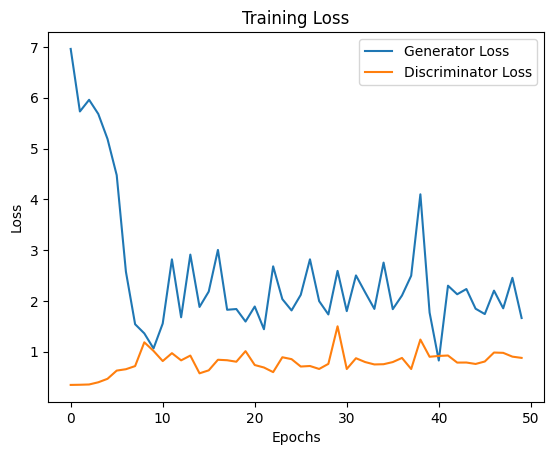

In [9]:
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()